# Calculate Silhouette scores with bootstrapping method

Determine if there is a significant improvement in clustering after QC.

In [ ]:
import pathlib
import warnings

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score

# Ignore warning about deprecated argument name in sklearn
warnings.filterwarnings("ignore", message="'force_all_finite' was renamed")

In [2]:
# Output dir for figure
output_dir = pathlib.Path("./figures")
output_dir.mkdir(exist_ok=True, parents=True)

# Load in pre- and post-QC UMAP embeddings DataFrames
pre_QC_umap_df = pd.read_parquet(
    "../figure_3/umap_embeddings/pre_QC_umap_embeddings.parquet"
)
post_QC_umap_df = pd.read_parquet(
    "../figure_3/umap_embeddings/post_QC_umap_embeddings.parquet"
)

# Set min cluster size for HDBSCAN
min_cluster_size = 100

## Compute individual Silhouette scores

### Pre-QC UMAP score

In [3]:
# Calculate and print silhouette score for pre-QC datasets
pre_X = pre_QC_umap_df[["UMAP0", "UMAP1"]].values

# Run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
pre_cluster_labels = clusterer.fit_predict(pre_X)

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(pre_cluster_labels))
print("Cluster persistence:", clusterer.cluster_persistence_)

# Silhouette score (exclude noise points labeled as -1)
mask = pre_cluster_labels != -1
X_clustered = pre_X[mask]
labels_clustered = pre_cluster_labels[mask]
pre_QC_score = silhouette_score(X_clustered, labels_clustered)
print("Silhouette score (excluding noise):", pre_QC_score)

Unique cluster labels (-1 is noise): [-1  0  1  2]
Cluster persistence: [0.49510573 0.17298336 0.10313331]
Silhouette score (excluding noise): 0.4348263740539551


### Post-QC UMAP score

In [4]:
# Calculate and print silhouette scores for post-QC datasets
post_X = post_QC_umap_df[["UMAP0", "UMAP1"]].values

# Run HDBSCAN
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size)
post_cluster_labels = clusterer.fit_predict(post_X)

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(post_cluster_labels))
print("Cluster persistence:", clusterer.cluster_persistence_)

# Silhouette score (exclude noise points labeled as -1)
mask = post_cluster_labels != -1
post_X_clustered = post_X[mask]
labels_clustered = post_cluster_labels[mask]
post_QC_score = silhouette_score(post_X_clustered, labels_clustered)
print("Silhouette score (excluding noise):", post_QC_score)

Unique cluster labels (-1 is noise): [-1  0  1]
Cluster persistence: [0.15397601 0.28611643]
Silhouette score (excluding noise): 0.4423278272151947


# Visualize where passing or failing cells are within each cluster

cluster
0     2138
1     2831
2    20476
Name: count, dtype: int64


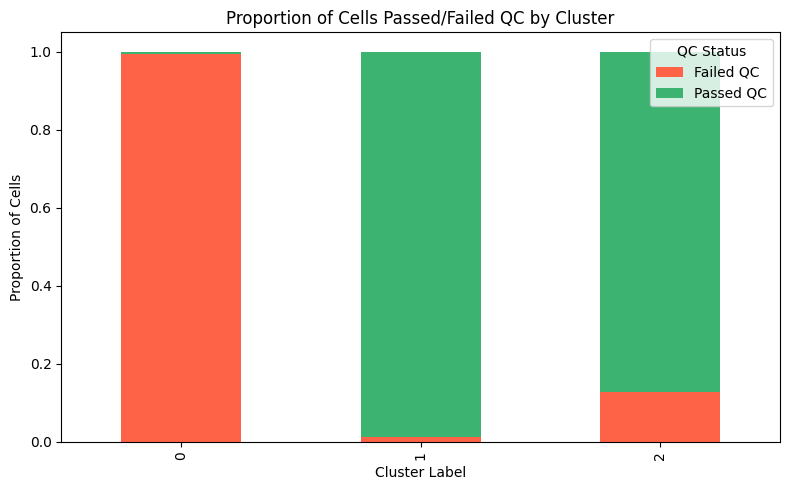

In [5]:
# Attach cluster labels to full dataframe
pre_QC_clusters_df = pre_QC_umap_df.copy()
pre_QC_clusters_df["cluster"] = pre_cluster_labels

# Drop noise
pre_QC_clusters_df = pre_QC_clusters_df[pre_QC_clusters_df["cluster"] != -1]

# Convert labels to string for nicer plotting
pre_QC_clusters_df["cluster"] = pre_QC_clusters_df["cluster"].astype(str)

# Print number of cells in each cluster
print(pre_QC_clusters_df["cluster"].value_counts().sort_index())

# Calculate proportions for each cluster
cluster_counts = (
    pre_QC_clusters_df.groupby(["cluster", "Metadata_QC_status"])
    .size()
    .unstack(fill_value=0)
)
cluster_props = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)

# Plot
ax = cluster_props.plot(
    kind="bar", stacked=True, color=["tomato", "mediumseagreen"], figsize=(8, 5)
)
ax.set_ylabel("Proportion of Cells")
ax.set_xlabel("Cluster Label")
ax.set_title("Proportion of Cells Passed/Failed QC by Cluster")
ax.legend(["Failed QC", "Passed QC"], title="QC Status")
plt.tight_layout()
plt.savefig(output_dir / "pre_QC_cluster_qc_status_proportions.png", dpi=300)
plt.show()

In [6]:
# Quantify number of failed vs passed cells in pre-QC cluster 0
cluster0_df = pre_QC_clusters_df[pre_QC_clusters_df["cluster"] == "0"]
failed_count = (cluster0_df["Metadata_QC_status"] == "failed").sum()
passed_count = (cluster0_df["Metadata_QC_status"] == "passed").sum()

print(f"Cluster 0 - Failed cells: {failed_count}")
print(f"Cluster 0 - Passed cells: {passed_count}")

Cluster 0 - Failed cells: 2126
Cluster 0 - Passed cells: 12
